# Dimensionality Reduction - PCA

This notebook is designed for classroom demonstration with clear comments and simple steps.

## Objective

In this notebook, we will demonstrate a basic **dimensionality reduction** machine learning flow.

## Basic Steps

1. Read the dataset  
2. Perform basic EDA  
3. Prepare input features and target  
4. Convert categorical columns into numeric columns  
5. Split data into training and testing sets  
6. Train the model  
7. Predict  
8. Evaluate using suitable metrics  
9. Save the trained model using pickle  

Dataset used: `customer_segmentation_1000.csv`


In [1]:
# ============================================================
# Import required libraries
# ============================================================

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Read dataset
df = pd.read_csv("../datasets/customer_segmentation_1000.csv")
df.head()

,annual_income,spending_score,website_visits,app_sessions,avg_order_value,orders_per_month,return_rate,loyalty_years,region,membership
0,2377900,60,17,25,7167.19,11,0.13,4.6,North,Silver
1,1328435,77,15,19,12314.62,6,0.16,6.5,North,Silver
2,1572299,82,18,23,3477.19,6,0.20,3.8,South,Platinum
3,1105309,56,15,20,4885.06,6,0.23,4.4,South,Gold
4,272884,9,10,15,6754.48,9,0.19,0.3,East,Silver


In [3]:
# Basic EDA
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
df.describe()

Dataset shape: (1000, 10)

Missing values:
annual_income       0
spending_score      0
website_visits      0
app_sessions        0
avg_order_value     0
orders_per_month    0
return_rate         0
loyalty_years       0
region              0
membership          0
dtype: int64


,annual_income,spending_score,website_visits,app_sessions,avg_order_value,orders_per_month,return_rate,loyalty_years
count,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.335486e+06,49.207000,12.175000,20.23100,7621.072740,4.952000,0.196350,5.873100
std,6.878873e+05,28.607141,3.579551,4.44583,4144.961912,2.207843,0.115276,3.444577
min,2.006170e+05,1.000000,3.000000,6.00000,322.890000,0.000000,0.000000,0.000000
25%,7.033290e+05,24.000000,10.000000,17.00000,4207.167500,3.000000,0.100000,2.900000
50%,1.363144e+06,50.000000,12.000000,20.00000,7520.460000,5.000000,0.190000,5.800000
75%,1.946781e+06,74.000000,14.000000,23.00000,11163.225000,6.000000,0.290000,8.825000
max,2.497496e+06,100.000000,25.000000,36.00000,14999.620000,12.000000,0.400000,12.000000


In [4]:
# Prepare data

# PCA is unsupervised dimensionality reduction.
# It reduces many input columns into fewer new columns called principal components.

X = pd.get_dummies(df, drop_first=True)

print("Original feature count:", X.shape[1])
X.head()

Original feature count: 13


,annual_income,spending_score,website_visits,app_sessions,avg_order_value,orders_per_month,return_rate,loyalty_years,region_North,region_South,region_West,membership_Platinum,membership_Silver
0,2377900,60,17,25,7167.19,11,0.13,4.6,True,False,False,False,True
1,1328435,77,15,19,12314.62,6,0.16,6.5,True,False,False,False,True
2,1572299,82,18,23,3477.19,6,0.20,3.8,False,True,False,True,False
3,1105309,56,15,20,4885.06,6,0.23,4.4,False,True,False,False,False
4,272884,9,10,15,6754.48,9,0.19,0.3,False,False,False,False,True


In [5]:
# Scale data

# PCA is affected by scale.
# So we scale the data before applying PCA.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed.")

Scaling completed.


In [6]:
# Apply PCA

# n_components=2 means we reduce all columns into 2 principal components.
# This is useful for visualization and simplification.

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df.head()

,PC1,PC2
0,1.678841,1.847126
1,1.357720,1.326143
2,-2.568122,-0.195798
3,-0.751895,-0.798040
4,0.851424,-0.203296


In [7]:
# ============================================================
# Evaluation/interpretation metrics for PCA
# ============================================================

# Explained variance ratio:
# Shows how much information is captured by each principal component.
# Example:
# If PC1 explains 30% and PC2 explains 20%,
# together they explain 50% of the original data variation.

explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", round(explained_variance[0], 4))
print("Explained variance by PC2:", round(explained_variance[1], 4))
print("Total explained variance :", round(explained_variance.sum(), 4))

Explained variance by PC1: 0.1108
Explained variance by PC2: 0.1052
Total explained variance : 0.216


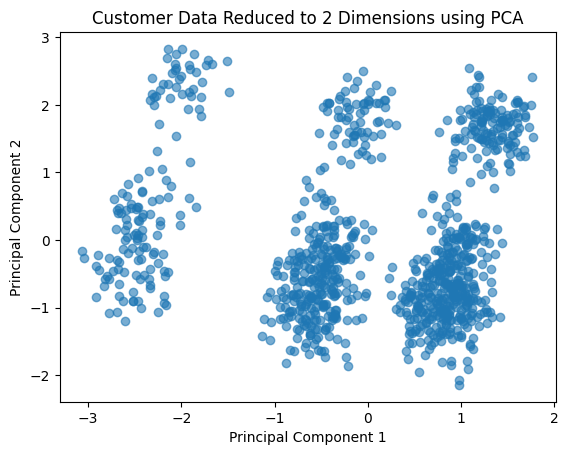

In [8]:
# Visualize PCA output

plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.6)
plt.title("Customer Data Reduced to 2 Dimensions using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [9]:
# Save PCA output
pca_df.to_csv("../datasets/customer_segmentation_pca_output.csv", index=False)

print("PCA output saved successfully.")

PCA output saved successfully.


In [10]:
# Save scaler and PCA model using pickle

pca_package = {
    "scaler": scaler,
    "pca": pca
}

model_path = "../models/pca_dimensionality_reduction.pkl"

with open(model_path, "wb") as file:
    pickle.dump(pca_package, file)

print("PCA model and scaler saved successfully at:", model_path)

PCA model and scaler saved successfully at: ../models/pca_dimensionality_reduction.pkl
